In [1]:
# base
import os
import gc
import pickle
from pathlib import Path
import warnings
import logging

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# data manipulation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import itables

itables.init_notebook_mode(all_interactive=True)

warnings.simplefilter("ignore", pd.errors.DtypeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import anndata as ad
import scanpy as sc

# import squidpy as sq
import spatialdata as sd
import spatialdata_plot as sdp
import spatialdata_io

# import cellcharter as cc
# import liana as li
import commot as ct

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

# # R
# import rpy2.robjects as ro
# from rpy2.robjects.conversion import localconverter

# %load_ext rpy2.ipython

# analysis & device specific
converter = get_converter()
CORES = 20
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")

%matplotlib inline
mpl.rcdefaults()


def AddPailinLabels(ax, adata, fontsize=10):
    for i in range(3):
        ax.text(
            (i + 0.5) / 3,
            0.97,
            adata.obs["batch"].cat.categories.to_list()[i],
            transform=ax.transAxes,
            ha="center",
            fontsize=fontsize / 2,
        )
    for i in range(3):
        ax.text(
            0.04,
            1 - (i + 0.5) / 3,
            adata.obs["timepoint"].cat.categories.to_list()[i],
            transform=ax.transAxes,
            va="center",
            ha="right",
            rotation=90,
            fontsize=fontsize,
        )


gc.collect()

95621

In [ ]:
adata = ad.read_zarr(DATADIR / "processed" / "external" / "neighborhood_analyzed")
adata

# Cell Communication

In [ ]:
ccc_db = liana_mouse_resource(
    [
        "baccin2019",
        "cellcall",
        "cellchatdb",
        "cellinker",
        "cellphonedbv5",
        "cellphonedb",
        "celltalkdb",
        "connectomedb2020",
        "consensus",
        "embrace",
        "guide2pharma",
        "hpmr",
        "icellnet",
        "italk",
        "kirouac2010",
        "lrdb",
        "ramilowski2015",
        "mouseconsensus",
    ]
)
ccc_db.to_csv(REFDIR / "ethan_ccc_database.csv")

Processing mouseconsensus: 100%|██████████| 18/18 [00:16<00:00,  1.10it/s] 


found lowercase letters in first cell 'Dll1' of 'mouseconsensus', not converting!


##### Bivariate analysis (Liana) -- designed for spot spatial

In [ ]:
lrdata = li.mt.bivariate(
    adata,
    local_name="cosine",  # Name of the function
    global_name="morans",  # Name global function
    n_perms=100,  # Number of permutations to calculate a p-value
    mask_negatives=True,  # Whether to mask LowLow/NegativeNegative interactions
    add_categories=True,  # Whether to add local categories to the results
    nz_prop=0.2,  # Minimum expr. proportion for ligands/receptors and their subunits
    layer="normalized",
    resource=ccc_db[["ligand", "receptor"]],
    n_jobs=10,
    use_raw=False,
    verbose=True,
)
lrdata

In [ ]:
N = 5
top_interactions = (
    lrdata.var.sort_values("mean", ascending=False).head(N).index.tolist()
    + lrdata.var.sort_values("morans", ascending=False).head(N).index.tolist()
)
top_interactions
sc.pl.spatial(
    lrdata[lrdata.obs["sample"] == samp1],
    color=top_interactions,
    spot_size=30,
    size=1.4,
    vmax=1,
    cmap="magma",
    ncols=N,
)
# sc.pl.spatial(lrdata[lrdata.obs['sample'] == samp1], color=['Scn2b^Mag', 'Trf^Gpr162'], spot_size=30, size=1.4, cmap='magma', layer='pvals', norm=mpl.colors.LogNorm())

In [ ]:
li.multi.nmf(
    lrdata, n_components=None, inplace=True, random_state=0, max_iter=200, verbose=True
)

##### Commot (from CellChat group)

In [ ]:
# Custom database
ctdata = ad.read_zarr(DATADIR / "processed" / "external" / "tools" / "Commot_custom")

# fix misnaming
datasets = ctdata.uns["commot-cellchat-info"]["df_ligrec"]["pathway"].unique()
ctdata.obsm["commot-cellchat-sum-receiver"].drop(columns="r-" + datasets, inplace=True)
ctdata.obsm["commot-cellchat-sum-sender"].drop(columns="s-" + datasets, inplace=True)
commot_keys = pd.Series(ctdata.obsp.keys())[
    pd.Series(ctdata.obsp.keys()).str.contains("commot")
]
for key in commot_keys[commot_keys.isin("commot-cellchat-" + datasets)]:
    del ctdata.obsp[key]

# transfer data
adata.uns["commot-custom-info"] = ctdata.uns["commot-cellchat-info"]
for key in ctdata.obsm.keys():
    if "commot" in key:
        adata.obsm[key.replace("cellchat", "custom")] = ctdata.obsm[key]
for key in ctdata.obsp.keys():
    if "commot" in key:
        adata.obsp[key.replace("cellchat", "custom")] = ctdata.obsp[key]

# CellChat database
ctdata = ad.read_zarr(DATADIR / "processed" / "external" / "tools" / "Commot_cellchat")
adata.uns["commot-cellchat-info"] = ctdata.uns["commot-cellchat-info"]

# transfer data
for key in ctdata.obsm.keys():
    if "commot" in key:
        adata.obsm[key] = ctdata.obsm[key]
for key in ctdata.obsp.keys():
    if "commot" in key:
        adata.obsp[key] = ctdata.obsp[key]

del ctdata

Commot Plots:

In [18]:
# adata.uns['commot-custom-info']['df_ligrec'] = adata.uns['commot-custom-info']['df_ligrec'].iloc[:,:2]
adata.uns["commot-custom-info"]["df_ligrec"]

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


Text(0.5, 1.0, 'Ifnar1-Erbb3 interaction, receiver')

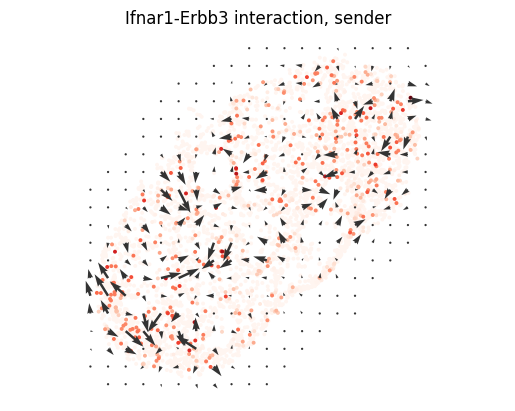

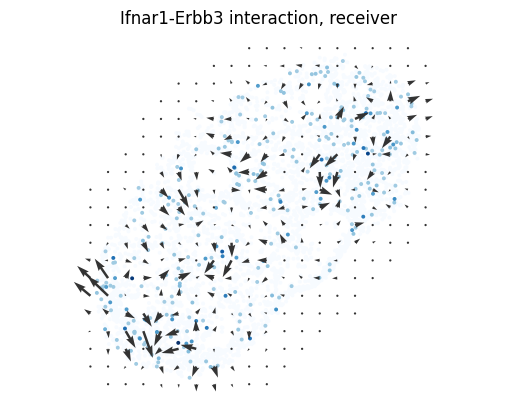

In [48]:
ct.tl.communication_direction(
    adata, database_name="custom", pathway_name="Ifnar1-Erbb3", k=5
)

# f,ax = plt.subplots(1,1, figsize=(10,10))
subset = adata[adata.obs["sample"] == "CU048_01_UCSF_brainstem_rep01_ST:pbs"]

ax = ct.pl.plot_cell_communication(
    subset,
    database_name="custom",
    lr_pair=["Ifnar1", "Erbb3"],
    # pathway_name="Ifnar1-Erbb3",
    plot_method="grid",
    scale=0.00003,
    ndsize=8,
    grid_density=0.4,
    summary="sender",
    background="summary",
    background_legend=True,
    cmap="Reds",
    normalize_v=True,
    normalize_v_quantile=0.995,
)
ax.set_title("Ifnar1-Erbb3 interaction, sender")

ax = ct.pl.plot_cell_communication(
    subset,
    database_name="custom",
    lr_pair=["Ifnar1", "Erbb3"],
    plot_method="grid",
    scale=0.00003,
    ndsize=8,
    grid_density=0.4,
    summary="receiver",
    background="summary",
    background_legend=True,
    cmap="Blues",
    normalize_v=True,
    normalize_v_quantile=0.995,
)
ax.set_title("Ifnar1-Erbb3 interaction, receiver")


# df_deg, df_yhat = ct.tl.communication_deg_detection(
#     ctdata, database_name="cellchat", pathway_name="TGFb", summary="receiver"
# )

Text(0.5, 1.0, 'Ifnar1-Erbb3 interaction, by neighborhood')

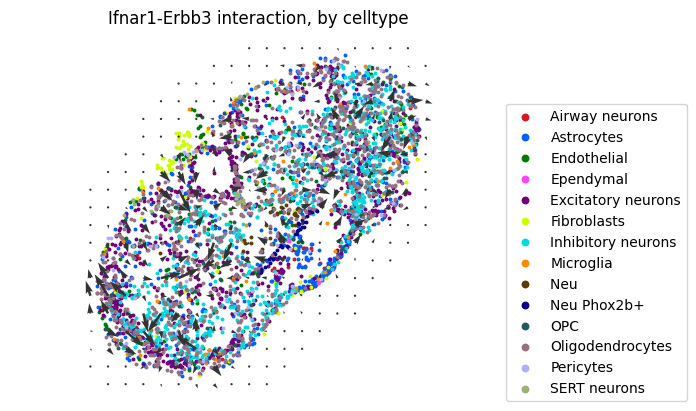

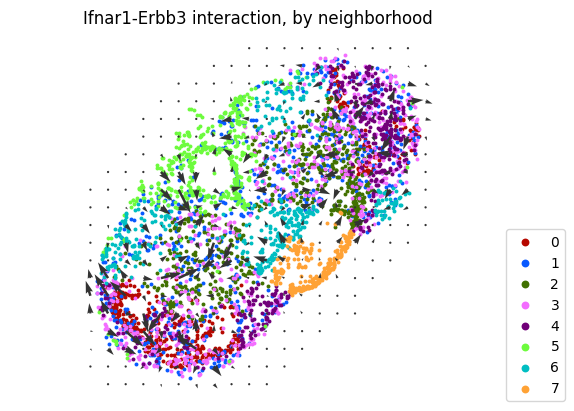

In [47]:
colorby = "celltype"
palette = color_gen(adata.obs[colorby], custom_index=adata.obs[colorby].cat.categories)
ax = ct.pl.plot_cell_communication(
    subset,
    database_name="custom",
    lr_pair=["Ifnar1", "Erbb3"],
    plot_method="grid",
    scale=0.00003,
    ndsize=8,
    grid_density=0.4,
    background="cluster",
    clustering=colorby,
    cluster_cmap=palette,
    background_legend=True,
    normalize_v=True,
    normalize_v_quantile=0.995,
)
ax.set_title("Ifnar1-Erbb3 interaction, by celltype")

colorby = "cellcharter_k8"
palette = color_gen(adata.obs[colorby], custom_index=adata.obs[colorby].cat.categories)
ax = ct.pl.plot_cell_communication(
    subset,
    database_name="custom",
    lr_pair=["Ifnar1", "Erbb3"],
    plot_method="grid",
    scale=0.00003,
    ndsize=8,
    grid_density=0.4,
    background="cluster",
    clustering=colorby,
    cluster_cmap=palette,
    background_legend=True,
    normalize_v=True,
    normalize_v_quantile=0.995,
)
ax.set_title("Ifnar1-Erbb3 interaction, by neighborhood")

In [20]:
# need to run `sudo apt-get install graphviz graphviz-dev`

ct.tl.cluster_communication(
    adata,
    database_name="custom",
    lr_pair=["Ifnar1", "Erbb3"],
    clustering="celltype",
    n_permutations=100,
)
ct.pl.plot_cluster_communication_network(
    adata,
    clustering="celltype",
    uns_names=["commot_cluster-celltype-cellchat-Ifnar1-Erbb3"],
    nx_bg_pos=False,
    nx_node_pos=None,
    # p_value_cutoff=5e-2,
    nx_node_cmap="Light24",
    filename="test.png",
)

KeyError: 'commot_cluster-celltype-cellchat-Ifnar1-Erbb3'

# Save/Load

In [ ]:
adata.write_zarr(DATADIR / "processed" / "external" / "analyzed-commot")

In [2]:
adata = ad.read_zarr(DATADIR / "processed" / "external" / "analyzed-commot")
adata

AnnData object with n_obs × n_vars = 36344 × 19059
    obs: 'batch', 'nCount_RNA', 'nFeature_RNA', 'number_clusters', 'percent.mt', 'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'x', 'y', 'celltype', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.30', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.40', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.50', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.60', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.70', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.80', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.90', 'BANKSY_labels_nonspatial_pc30_nc0.00_r1.00', 'BANKSY_labels_scaled_gaussian_pc30_nc0.20_r0.30', 'BANKSY_labels_scaled_ga